<a href="https://colab.research.google.com/github/Kazureee/Machine-Learning-Lesson/blob/main/Hierarchical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from matplotlib import pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/iris_cluster.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


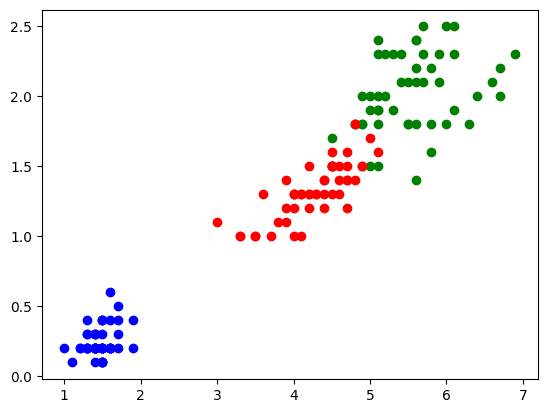

In [41]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.petal_length, df1.petal_width, color='green')
plt.scatter(df2.petal_length, df2.petal_width, color='blue')
plt.scatter(df3.petal_length, df3.petal_width, color='red')

In [42]:
from sklearn.model_selection import train_test_split
y = df.cluster
x = df.drop(['cluster', 'species'], axis='columns')

#partition data(Training dataset (80), testing dataset (20))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

x_test

,sepal_length,sepal_width,petal_length,petal_width
144,6.7,3.3,5.7,2.5
90,5.5,2.6,4.4,1.2
53,5.5,2.3,4.0,1.3
94,5.6,2.7,4.2,1.3
30,4.8,3.1,1.6,0.2
84,5.4,3.0,4.5,1.5
80,5.5,2.4,3.8,1.1
24,4.8,3.4,1.9,0.2
111,6.4,2.7,5.3,1.9
66,5.6,3.0,4.5,1.5


In [46]:
#K Means Clustering (Training)
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)
km.fit_predict(x_train, y_train)

array([1, 1, 2, 1, 0, 2, 1, 1, 0, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 0, 1, 0,
       2, 2, 2, 1, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 1, 2, 0, 0, 2, 1,
       1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 2, 1, 0, 0, 1, 0, 1, 0, 2, 0, 1,
       0, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 1, 0, 0, 1, 2, 2, 0, 2, 0, 0, 0,
       1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 1, 2, 2, 1, 1, 2, 1, 0, 2, 1, 0, 1,
       1, 2, 2, 2, 1, 2, 1, 0, 0, 0], dtype=int32)

In [47]:
#K Means prediction (Testing)
y_km_predicted = km.fit_predict(x_test)
y_km_predicted

array([1, 2, 2, 2, 0, 2, 2, 0, 1, 2, 2, 0, 0, 1, 1, 2, 0, 1, 0, 2, 0, 0,
       2, 0, 0, 1, 0, 1, 1, 1], dtype=int32)

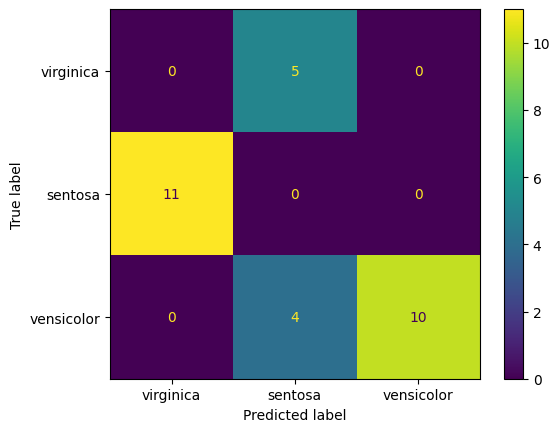

In [48]:
#Confusion Matrix (K Means) (Evalution)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_km_predicted)
cm

cm_display = ConfusionMatrixDisplay(cm, display_labels=['virginica', 'sentosa', 'vensicolor'])
cm_display.plot()